#### This file finds the scattering parameter and adds it to the data

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

#### Import Data

In [101]:
experimental_path = "Spectral_library_experimental_scattering.xlsx"
df_experimental = pd.read_excel(experimental_path)

clean_path = "Spectral_library_clean.xlsx"
df_clean = pd.read_excel(clean_path)

same_sample_path = "Spectral_library_same_sample.xlsx"
df_same_sample = pd.read_excel(same_sample_path)

#### Compare Experimental Scattering Data with Unscattered Data

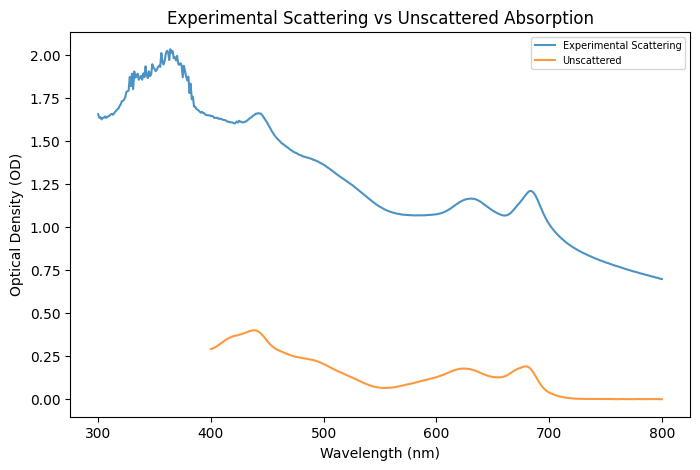

In [91]:
wavelength_col = "Wavelength"
cyano_col = "Cyanobacteria_Synechosystis"

experimental_wavelengths = df_experimental[wavelength_col].values
experimental_spectrum = df_experimental[cyano_col].values
unscattered_wavelengths = df_clean[wavelength_col].values
unscattered_spectrum = df_clean[cyano_col].values


plt.figure(figsize=(8, 5))
plt.plot(experimental_wavelengths, experimental_spectrum, label="Experimental Scattering", alpha=0.8)
plt.plot(unscattered_wavelengths, unscattered_spectrum, label="Unscattered", alpha=0.8)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Optical Density (OD)")
plt.title("Experimental Scattering vs Unscattered Absorption")
plt.legend(fontsize=7)
plt.show()

#### Fit scattering

In [92]:
def fitting_function(wavelengths_nm, a, n, c):
    lam = wavelengths_nm.astype(float)
    lambda_ref = 600
    return a * (lam / lambda_ref) ** (-n) + c
mask = (experimental_wavelengths >= 770) & (experimental_wavelengths <= 800)
wl_fit = experimental_wavelengths[mask]
A_fit  = experimental_spectrum[mask]

p0 = (0.1, 1.0, 0.0)
popt, pcov = curve_fit(fitting_function, wl_fit, A_fit, p0=p0, maxfev = 200000)
a_hat, n_hat, c_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  n={n_hat:.4f},  c={c_hat:.6f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δn={perr[1]:.4f},  Δc={perr[2]:.6f}")

Fitted parameters:  a=1.3404,  n=1.6393,  c=-0.138703
Parameter uncertainties:  Δa=0.3003,  Δn=0.6556,  Δc=0.345230


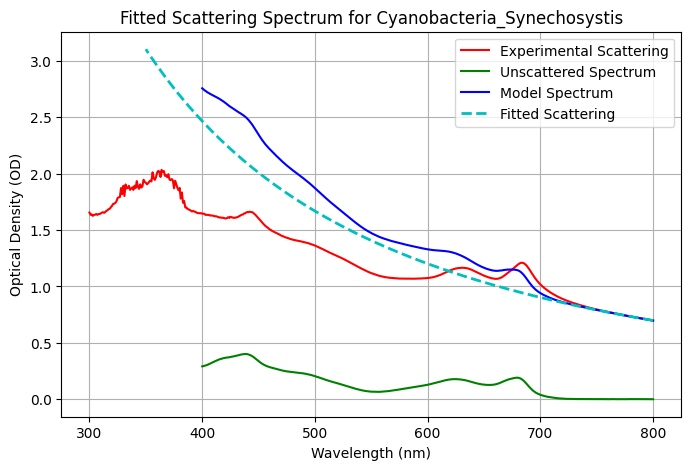

In [93]:
wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = fitting_function(wl_full, a=a_hat, n=n_hat, c=c_hat)

model_spectrum = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'g', label='Unscattered Spectrum')
plt.plot(wl_full, model_spectrum, 'b', label='Model Spectrum')
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Fitted Scattering Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()


#### Fit on scattering only

Fitted parameters:  a=1.0675,  n=0.8448,  c=-0.1000
Parameter uncertainties:  Δa=0.1626,  Δn=0.1286,  Δc=0.1605


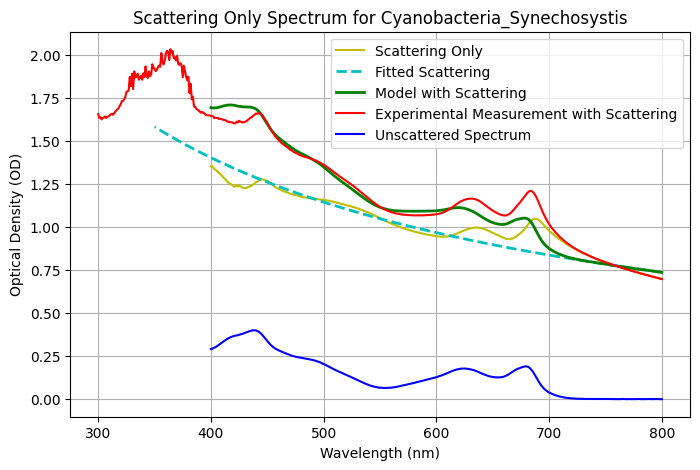

In [94]:
scattering_only = pd.DataFrame(columns=["Wavelength", "Optical Density"])
mask = (experimental_wavelengths >= 350) & (experimental_wavelengths <= 800)
scattering_only["Wavelength"] = experimental_wavelengths[mask]
scattering_only["Optical Density"] = experimental_spectrum[mask] - unscattered_spectrum

scattering_only_wavelengths = scattering_only["Wavelength"]
scattering_only_optical_density = scattering_only["Optical Density"]

scattering_only["Optical Density"] = scattering_only["Optical Density"].replace(np.nan, 0)

# fit away from absorption peaks, over a wide range
mask = (
    ((scattering_only_wavelengths >= 450) & (scattering_only_wavelengths <= 600)) |
    ((scattering_only_wavelengths >= 720) & (scattering_only_wavelengths <= 800))
)
wl_fit = scattering_only_wavelengths[mask].values.astype(float)
A_fit  = scattering_only_optical_density[mask].values.astype(float)

p0 = [1.0, 1.0, 0.0]
# bounds the fitted parameters in some regime. We know it's Mie, so .3< n <2.5
bounds = ([0,   0.3,  -0.1],[5,   2.5,   0.3])

popt, pcov = curve_fit(
    fitting_function, wl_fit, A_fit,
    p0=p0, bounds=bounds, maxfev=200
)
a_hat, n_hat, c_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  n={n_hat:.4f},  c={c_hat:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δn={perr[1]:.4f},  Δc={perr[2]:.4f}")

wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = fitting_function(wl_full, a=a_hat, n=n_hat, c=c_hat)
model_scattering_only = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(scattering_only_wavelengths, scattering_only_optical_density, 'y', label='Scattering Only', markersize=4)
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.plot(wl_full, model_scattering_only, 'g', label='Model with Scattering', linewidth=2)
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Measurement with Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'b', label='Unscattered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Scattering Only Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()

Fitted parameters:  a=-0.0014,  b=1.8307
Parameter uncertainties:  Δa=0.0000,  Δb=0.0124


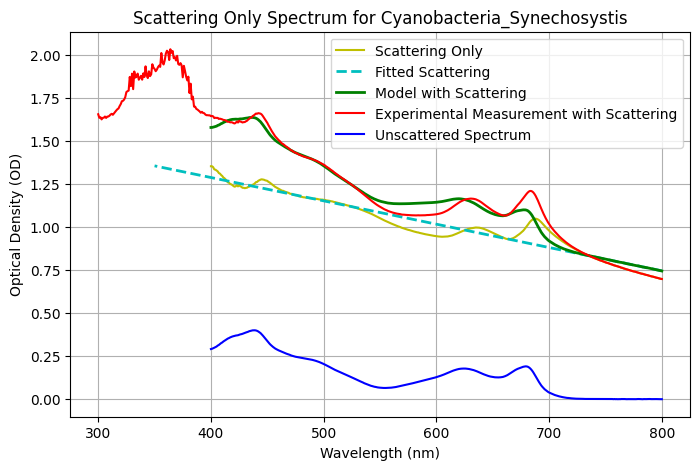

In [95]:
def linear_fitting_function(wavelengths_nm, a, b):
        return a * wavelengths_nm + b

scattering_only = pd.DataFrame(columns=["Wavelength", "Optical Density"])
mask = (experimental_wavelengths >= 350) & (experimental_wavelengths <= 800)
scattering_only["Wavelength"] = experimental_wavelengths[mask]
scattering_only["Optical Density"] = experimental_spectrum[mask] - unscattered_spectrum

scattering_only_wavelengths = scattering_only["Wavelength"]
scattering_only_optical_density = scattering_only["Optical Density"]

scattering_only["Optical Density"] = scattering_only["Optical Density"].replace(np.nan, 0)
mask = (scattering_only_wavelengths >= 400) & (scattering_only_wavelengths <= 800)
wl_fit = scattering_only_wavelengths[mask]
A_fit  = scattering_only_optical_density[mask]

p0 = (0.1, 1.0)
popt, pcov = curve_fit(linear_fitting_function, wl_fit, A_fit, p0=p0)
a_hat, b_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  b={b_hat:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δb={perr[1]:.4f}")

wl_full = unscattered_wavelengths
A_full = unscattered_spectrum
fitted_scattering = linear_fitting_function(wl_full, a=a_hat, b=b_hat)
model_scattering_only = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(scattering_only_wavelengths, scattering_only_optical_density, 'y', label='Scattering Only', markersize=4)
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.plot(wl_full, model_scattering_only, 'g', label='Model with Scattering', linewidth=2)
plt.plot(experimental_wavelengths, experimental_spectrum, 'r', label='Experimental Measurement with Scattering', markersize=4)
plt.plot(unscattered_wavelengths, unscattered_spectrum, 'b', label='Unscattered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Scattering Only Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()

#### Comparing Scattering and Without Scattering of Same Sample

Scattering only spectrum (350 nm): 0.6273813989999999
Scattering only spectrum (750 nm): 0.47639603399999997


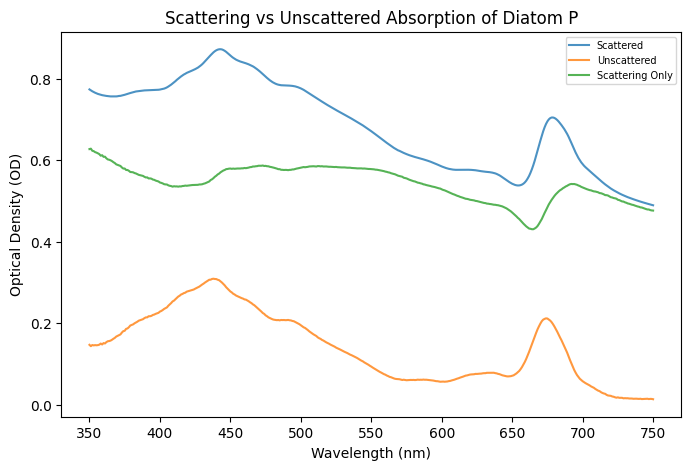

In [105]:
wavelength_diatom_col = "Wavelength (nm)"
scatter_col = "with_scattering"
unscatter_col = "without_scattering"

wavelengths = df_same_sample[wavelength_diatom_col].values
scattered_spectrum = df_same_sample[scatter_col].values
unscattered_spectrum = df_same_sample[unscatter_col].values

scatter_only_spectrum = scattered_spectrum - unscattered_spectrum
print(f"Scattering only spectrum (350 nm): {scatter_only_spectrum[-1]}")
print(f"Scattering only spectrum (750 nm): {scatter_only_spectrum[0]}")


plt.figure(figsize=(8, 5))
plt.plot(wavelengths, scattered_spectrum, label="Scattered", alpha=0.8)
plt.plot(wavelengths, unscattered_spectrum, label="Unscattered", alpha=0.8)
plt.plot(wavelengths, scatter_only_spectrum, label="Scattering Only", alpha=0.8)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Optical Density (OD)")
plt.title("Scattering vs Unscattered Absorption of Diatom P")
plt.legend(fontsize=7)
plt.show()

Fitted parameters:  a=0.6414,  n=0.3263,  c=-0.1000
Parameter uncertainties:  Δa=0.7778,  Δn=0.3921,  Δc=0.7768


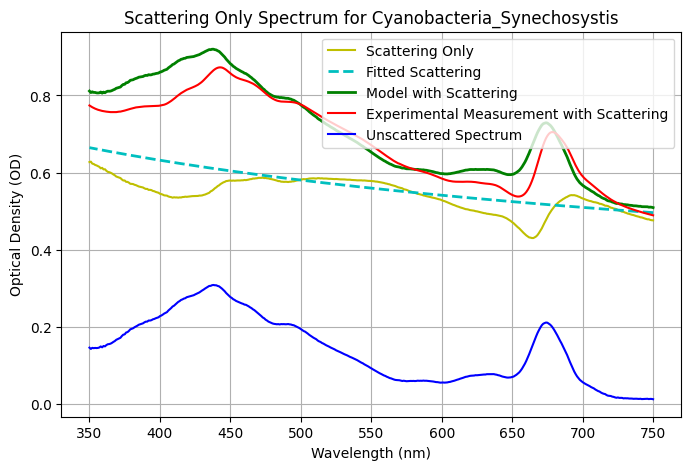

In [106]:
scattering_fit_diatom = pd.DataFrame(columns=["Wavelength", "Optical Density"])
mask = (wavelengths >= 350) & (wavelengths <= 750)
scattering_fit_diatom["Wavelength"] = wavelengths[mask]
scattering_fit_diatom["Optical Density"] = scatter_only_spectrum[mask]

scattering_fit_diatom_wavelengths = scattering_fit_diatom["Wavelength"]
scattering_fit_diatom_optical_density = scattering_fit_diatom["Optical Density"]

scattering_fit_diatom_optical_density = scattering_fit_diatom_optical_density.replace(np.nan, 0)

# fit away from absorption peaks, over a wide range
mask = (
    ((scattering_fit_diatom_wavelengths >= 450) & (scattering_fit_diatom_wavelengths <= 600)) |
    ((scattering_fit_diatom_wavelengths >= 720) & (scattering_fit_diatom_wavelengths <= 800))
)
wl_fit = scattering_fit_diatom_wavelengths[mask].values.astype(float)
A_fit  = scattering_fit_diatom_optical_density[mask].values.astype(float)

p0 = [1.0, 1.0, 0.0]
# bounds the fitted parameters in some regime. We know it's Mie, so .3< n <2.5
bounds = ([0,   0.3,  -0.1],[5,   2.5,   0.3])

popt, pcov = curve_fit(
    fitting_function, wl_fit, A_fit,
    p0=p0, bounds=bounds, maxfev=200
)
a_hat, n_hat, c_hat = popt
print(f"Fitted parameters:  a={a_hat:.4f},  n={n_hat:.4f},  c={c_hat:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Parameter uncertainties:  Δa={perr[0]:.4f},  Δn={perr[1]:.4f},  Δc={perr[2]:.4f}")

wl_full = wavelengths
A_full = unscattered_spectrum
fitted_scattering = fitting_function(wl_full, a=a_hat, n=n_hat, c=c_hat)
model_scattering_only = A_full + fitted_scattering

plt.figure(figsize=(8, 5))
plt.plot(scattering_fit_diatom_wavelengths, scattering_fit_diatom_optical_density, 'y', label='Scattering Only', markersize=4)
plt.plot(wl_full, fitted_scattering, 'c--', label='Fitted Scattering', linewidth=2)
plt.plot(wl_full, model_scattering_only, 'g', label='Model with Scattering', linewidth=2)
plt.plot(wavelengths, scattered_spectrum, 'r', label='Experimental Measurement with Scattering', markersize=4)
plt.plot(wavelengths, unscattered_spectrum, 'b', label='Unscattered Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Optical Density (OD)')
plt.title('Scattering Only Spectrum for Cyanobacteria_Synechosystis')
plt.legend()
plt.grid()
plt.show()

#### Species Size and Exponent Relation

C:\Users\matsa\AppData\Local\Temp\ipykernel_18560\421071977.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_fit, pcov_fit = curve_fit(fitting_exponents, d_fit, n_fit_vals, p0=p0_fit)


Fit based on measured exponents:  n(d) = a*exp(b*d)
  a_meas = 3.525,  b_meas = -0.8901
Fit based on fitted_exponents:    n(d) = a*exp(b*d)
  a_fit  = 0.880,  b_fit  = -0.0460

Species                              d[µm] n_theory n_fit_theory n_observed n_fit_observed
--------------------------------------------------------------------------------------
Ptri                                 22.00      nan       0.00      0.32       0.32
Csplx                                24.00      nan       0.00       nan       0.29
Cpri                                  5.00      nan       0.04       nan       0.70
Crein                                16.00      nan       0.00       nan       0.42
Sym                                  13.00      nan       0.00       nan       0.48
Smic                                 10.00      nan       0.00       nan       0.56
Dtre                                 10.00      nan       0.00       nan       0.56
Cgor                                 10.00      nan      

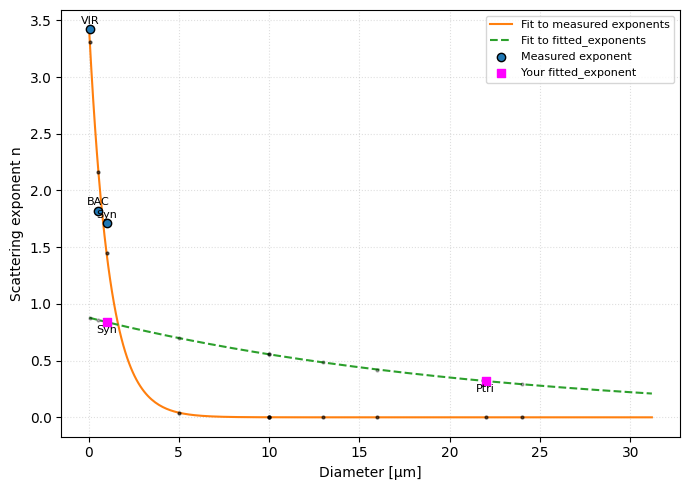

In [111]:
data = {
    "Diatom_Ptricornutum": {"diameter": 22, "exponent": 0, "fitted_exponent": 0.32},
    "Diatom_Csimplex": {"diameter": 24, "exponent": 0},
    "Chlamydomonas_Cpriscuii": {"diameter": 5},
    "Chlamydomonas_Creindhardtii": {"diameter": 16},
    "Dinoflagellate_Symbiodiniumsp": {"diameter": 13},
    "Dinoflagellate_Smicroadriaticum": {"diameter": 10},
    "Dinoflagellate_Dtrenchii": {"diameter": 10},
    "Dinoflagellate_Cgoreaui": {"diameter": 10},
    "Cyanobacteria_Synechosystis": {"diameter": 1, "exponent": 1.71, "fitted_exponent": 0.84},
    "VIR": {"diameter": 0.07, "exponent": 3.42},
    "BAC": {"diameter": 0.55, "exponent": 1.82},
}

short_labels = {
    "Diatom_Ptricornutum": "Ptri",
    "Diatom_Csimplex": "Csplx",
    "Chlamydomonas_Cpriscuii": "Cpri",
    "Chlamydomonas_Creindhardtii": "Crein",
    "Dinoflagellate_Symbiodiniumsp": "Sym",
    "Dinoflagellate_Smicroadriaticum": "Smic",
    "Dinoflagellate_Dtrenchii": "Dtre",
    "Dinoflagellate_Cgoreaui": "Cgor",
    "Cyanobacteria_Synechosystis": "Syn",
    "VIR": "VIR",
    "BAC": "BAC",
}

def fitting_exponents(diameter, a, b):
    return a * np.exp(b * diameter)

# -------------------------------
# 1) Build arrays for the two fits
# -------------------------------

# Fit 1: based on measured exponents (ignore 0 → treat as missing)
d_meas, n_meas, names_meas = [], [], []
for name, props in data.items():
    if "exponent" in props and props["exponent"] > 0:
        d_meas.append(props["diameter"])
        n_meas.append(props["exponent"])
        names_meas.append(name)

d_meas = np.array(d_meas)
n_meas = np.array(n_meas)

# Fit 2: based on fitted_exponent values
d_fit, n_fit_vals, names_fit = [], [], []
for name, props in data.items():
    if "fitted_exponent" in props:
        d_fit.append(props["diameter"])
        n_fit_vals.append(props["fitted_exponent"])
        names_fit.append(name)

d_fit = np.array(d_fit)
n_fit_vals = np.array(n_fit_vals)

# -------------------------------
# 2) Perform the two exponential fits
# -------------------------------

# Reasonable initial guesses: a ~ n at smallest diameter, b negative
p0_meas = (n_meas.max(), -0.1)
popt_meas, pcov_meas = curve_fit(fitting_exponents, d_meas, n_meas, p0=p0_meas)

p0_fit = (n_fit_vals.max(), -0.05)
popt_fit, pcov_fit = curve_fit(fitting_exponents, d_fit, n_fit_vals, p0=p0_fit)

print("Fit based on measured exponents:  n(d) = a*exp(b*d)")
print(f"  a_meas = {popt_meas[0]:.3f},  b_meas = {popt_meas[1]:.4f}")
print("Fit based on fitted_exponents:    n(d) = a*exp(b*d)")
print(f"  a_fit  = {popt_fit[0]:.3f},  b_fit  = {popt_fit[1]:.4f}")
print()

# -------------------------------
# 3) Evaluate both fits for all species and print table
# -------------------------------

print(f"{'Species':35s} {'d[µm]':>6s} {'n_theory':>8s} {'n_fit_theory':>10s} {'n_observed':>9s} {'n_fit_observed':>10s}")
print("-"*86)

for name, props in data.items():
    d = props["diameter"]
    n_obs = props.get("exponent", np.nan)
    n_obs_fitted = props.get("fitted_exponent", np.nan)

    n_pred_meas = fitting_exponents(d, *popt_meas)
    n_pred_fit = fitting_exponents(d, *popt_fit)

    print(f"{short_labels.get(name, name):35s} "
          f"{d:6.2f} "
          f"{(n_obs if n_obs!=0 else np.nan):8.2f} "
          f"{n_pred_meas:10.2f} "
          f"{n_obs_fitted:9.2f} "
          f"{n_pred_fit:10.2f}")

# -------------------------------
# 4) Plot both fitted curves and all species
# -------------------------------

all_diam = np.array([props["diameter"] for props in data.values()])
d_min, d_max = all_diam.min(), all_diam.max()
d_plot = np.linspace(d_min*0.7, d_max*1.3, 300)

plt.figure(figsize=(7,5))

# Fitted curves
plt.plot(d_plot, fitting_exponents(d_plot, *popt_meas),
         "C1-", label="Fit to measured exponents")
plt.plot(d_plot, fitting_exponents(d_plot, *popt_fit),
         "C2--", label="Fit to fitted_exponents")

# Measured exponents
plt.scatter(d_meas, n_meas, color="C0", edgecolor="k",
            zorder=3, label="Measured exponent")
for x, y, name in zip(d_meas, n_meas, names_meas):
    plt.text(x, y+0.05, short_labels[name], fontsize=8, ha="center")

# Fitted_exponent points
plt.scatter(d_fit, n_fit_vals, color="magenta", marker="s",
            zorder=3, label="Your fitted_exponent")
for x, y, name in zip(d_fit, n_fit_vals, names_fit):
    plt.text(x, y-0.10, short_labels[name], fontsize=8, ha="center")

# Predicted positions of all species on both curves (optional markers)
for name, props in data.items():
    d = props["diameter"]
    x = d
    y1 = fitting_exponents(d, *popt_meas)
    y2 = fitting_exponents(d, *popt_fit)
    # small grey markers to show where each species lies on each curve
    plt.plot(x, y1, "k.", ms=4, alpha=0.6)
    plt.plot(x, y2, "k.", ms=4, alpha=0.3)

plt.xlabel("Diameter [µm]")
plt.ylabel("Scattering exponent n")
plt.grid(True, ls=":", alpha=0.4)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Add scattering to all species